In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aftab\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
df = pd.read_csv("amazonreviews.tsv", sep='\t')

print(df.head())
print("Shape:", df.shape)

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
Shape: (10000, 2)


In [3]:
# Remove duplicates
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

print("After Cleaning:", df.shape)

After Cleaning: (10000, 2)


In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                      
    text = re.sub(r'[^a-zA-Z]', ' ', text)   
    words = text.split()
    words = [w for w in words if w not in stop_words] 
    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

In [5]:
df['label'] = df['label'].map({'pos': 1, 'neg': 0})

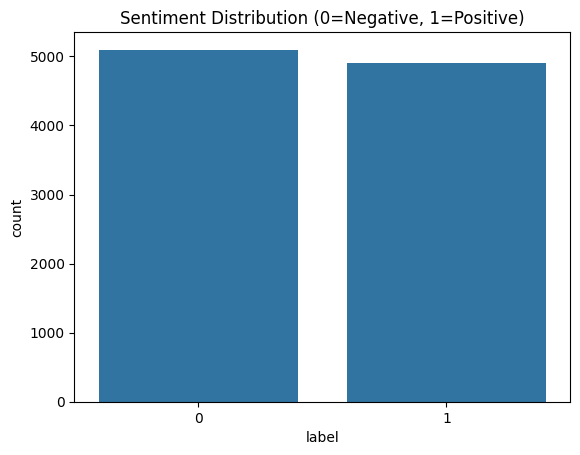

In [6]:
sns.countplot(x='label', data=df)
plt.title("Sentiment Distribution (0=Negative, 1=Positive)")
plt.show()

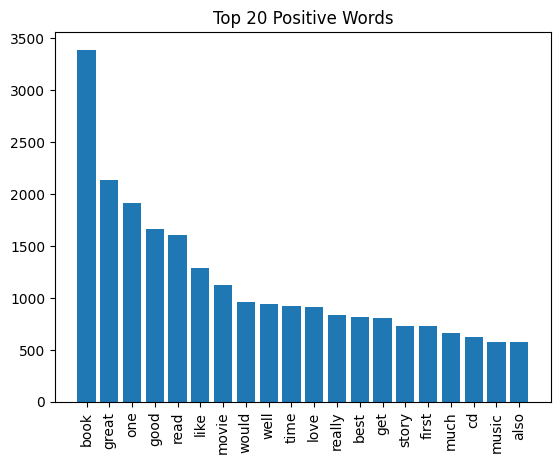

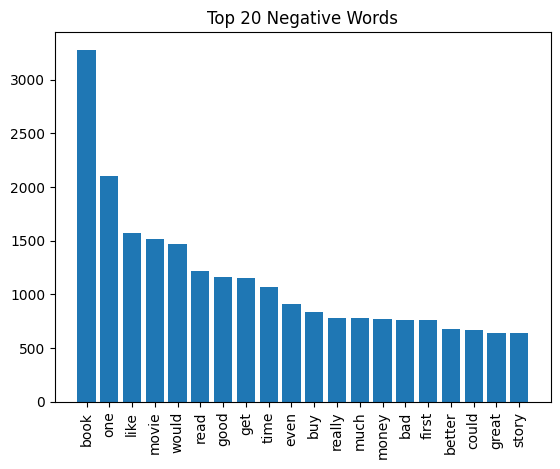

In [7]:
from collections import Counter

# Positive words
pos_words = []
for text in df[df['label'] == 1]['clean_review']:
    pos_words.extend(text.split())

common_pos = Counter(pos_words).most_common(20)

words = [w[0] for w in common_pos]
counts = [w[1] for w in common_pos]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Positive Words")
plt.show()

# Negative words
neg_words = []
for text in df[df['label'] == 0]['clean_review']:
    neg_words.extend(text.split())

common_neg = Counter(neg_words).most_common(20)

words = [w[0] for w in common_neg]
counts = [w[1] for w in common_neg]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=90)
plt.title("Top 20 Negative Words")
plt.show()

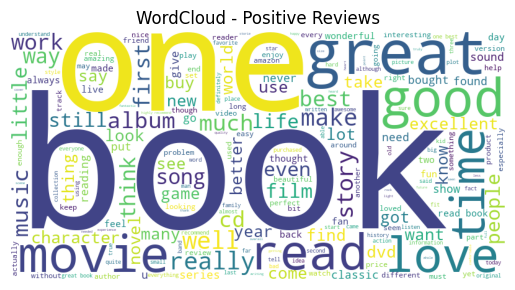

In [8]:
from wordcloud import WordCloud

# Join all positive reviews
pos_text = " ".join(df[df['label'] == 1]['clean_review'])

# Generate WordCloud
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
plt.figure()
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title("WordCloud - Positive Reviews")
plt.show()

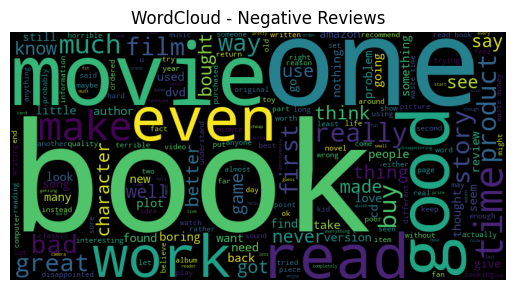

In [9]:
# Join all negative reviews
neg_text = " ".join(df[df['label'] == 0]['clean_review'])

# Generate WordCloud
wordcloud_neg = WordCloud(width=800, height=400, background_color='black').generate(neg_text)
plt.figure()
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title("WordCloud - Negative Reviews")
plt.show()

In [10]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review']).toarray()
y = df['label']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.851


In [13]:
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8525


In [14]:
print("\n--- Logistic Regression Report ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- SVM Report ---")
print(classification_report(y_test, y_pred_svm))


--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1037
           1       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000


--- SVM Report ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1037
           1       0.84      0.85      0.85       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



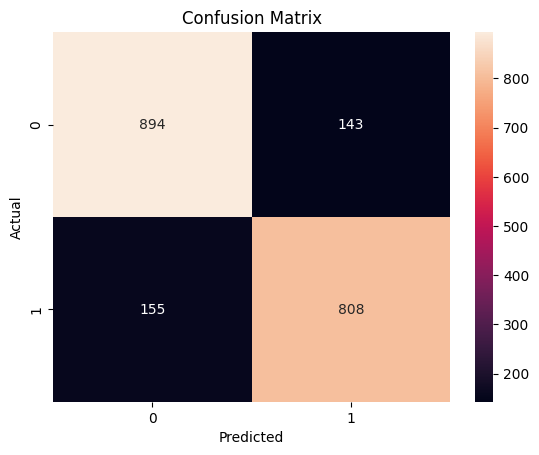

In [15]:
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
scores = cross_val_score(lr_model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [0.8595 0.83   0.827  0.8455 0.8505]
Average Accuracy: 0.8424999999999999
